# Notebook 10 — Left and Right Morphing Asymmetry

> **Supplementary §11**

The morphing shape modes are defined from unilateral data — left and right sides analysed separately. This notebook compares left and right morphing scores to assess whether hawks morph their wings symmetrically or independently.

We use **major-axis (MA) regression** (the first eigenvector of a 2-component PCA on paired left and right scores) on left vs right scores: a slope near 1 and intercept near 0 indicates bilaterally symmetric control; deviations indicate independent left-right morphing. We examine symmetry across multiple flight contexts including flapping vs gliding, obstacle flights, and naive vs experienced hawks.

## Contents
1. [Setup and data loading](#setup)
2. [Reading the symmetry plots](#reading-the-symmetry-plots)
3. [All non-obstacle flights](#all-non-obstacle-flights)
4. [Flapping (acceleration phase)](#flapping-phase-acceleration)
5. [Gliding (deceleration phase)](#gliding-phase-deceleration)
6. [Obstacle flights — before and after](#obstacle-flights)
7. [Naive hawks](#naive-hawks)
8. [Time series of left/right scores](#time-series-of-left-and-right-scores)
9. [Validating the symmetry assumption for modes 1 and 2](#validating-the-symmetry-assumption-for-modes-1-and-2)
10. [Summary](#summary)

In [1]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=3)

from kinematic_morphospace import (
    filter_by, run_PCA,
    get_score_df,
)
from kinematic_morphospace.plotting import (
    prepare_left_right_comparison, plot_left_right,
    plot_left_right_just_two, plot_left_right_empty,
    plot_score, print_symmetry_summary, save_figure,
)

# ── Configuration ──
CONFIG = {
    "alpha_all":        0.1,   # transparency: all non-obstacle flights (dense)
    "alpha_flapping":   0.5,   # flapping subsets
    "alpha_gliding":    0.3,   # gliding subsets
    "alpha_obstacle":   0.8,   # obstacle flights (sparse)
    "alpha_naive":      0.2,   # naive hawk subsets
    "bin_size":         0.05,  # horizontal-distance bin width (m)
    "fig_dir":          "../../figures/supplementary",
}

## Load Data and Run PCA

We load the unilateral data and rerun PCA (trained on non-obstacle flights, projected onto all data) to obtain the scores needed for left/right comparison.

In [2]:
unilateral_data = np.load("../../data/unilateral/data.npy")
unilateral_frame_info_df = pd.read_csv("../../data/unilateral/frame_info.csv")

filt = filter_by(unilateral_frame_info_df, obstacle=0)
principal_components, scores, pca = run_PCA(unilateral_data[filt], unilateral_data)

# Create scores dataframe with binning
scores_df, _ = get_score_df(scores, unilateral_frame_info_df, size_bin=CONFIG["bin_size"])

# ── Data summary ──
print(f"Total frames:  {scores.shape[0]:,}")
print(f"Modes:         {scores.shape[1]}")
print(f"Scores df:     {scores_df.shape}")
print()
n_obs    = filter_by(unilateral_frame_info_df, obstacle=0).sum()
n_obst   = filter_by(unilateral_frame_info_df, obstacle=1).sum()
n_naive  = filter_by(unilateral_frame_info_df, naive=1).sum()
n_exp    = filter_by(unilateral_frame_info_df, naive=0).sum()
print(f"Non-obstacle:  {n_obs:,}")
print(f"Obstacle:      {n_obst:,}")
print(f"Experienced:   {n_exp:,}")
print(f"Naive:         {n_naive:,}")

  Sign conventions applied: PC07 negated (positive = m-folded)
Total frames:  289,528
Modes:         12
Scores df:     (289528, 27)

Non-obstacle:  252,630
Obstacle:      36,898
Experienced:   95,498
Naive:         194,030


### Reading the Symmetry Plots

Each panel shows a scatter plot of right-side scores (x-axis) against left-side scores (y-axis) for one morphing mode. Two reference lines are drawn:

- **Grey solid line (x = y):** line of perfect bilateral symmetry
- **Black dotted line:** major-axis (MA) regression fit

The MA equation and percentage of variance along the major axis are annotated. If left and right scores are tightly coupled, the scatter lies along x = y with the MA slope near 1.0.

### Interpreting MA slope and intercept

- **Slope = 1.0:** Left and right sides change by equal amounts — perfectly symmetric morphing.
- **Slope > 1.0:** The left side exaggerates the morphing movement relative to the right (or vice versa).
- **Intercept ≈ 0:** No systematic offset between sides.
- **Intercept ≠ 0:** A persistent asymmetry — one side is consistently deflected relative to the other.


Number of frames: 131865
Number of flights: 1380


(<Figure size 200x200 with 1 Axes>,
 <Axes: xlabel='right scores', ylabel='left scores'>)

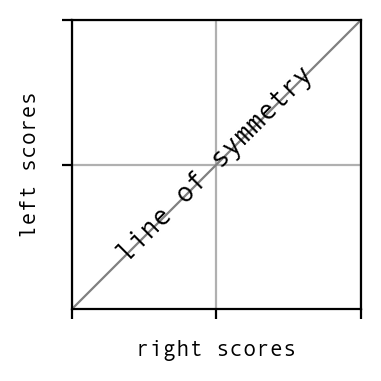

In [3]:
# Show an example empty plot to illustrate the layout
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df, obstacle=0
)
plot_left_right_empty(score_5, score_95, PC=0)

### A note on modes 1 and 2

The rotation correction (§5) assumes that modes 1 and 2 are bilaterally symmetric, using them as the reference for estimating whole-body rotation. This means the corrected scores for these two modes have symmetry built in by construction — so the left-right plots for modes 1–2 in the figures below cannot be taken at face value. We return to this in §9, where we validate the assumption using uncorrected data.

## All Non-Obstacle Flights

We first examine left/right symmetry across all non-obstacle flights from all hawks. This provides a baseline view of bilateral coupling. We expect strong bilateral symmetry in the dominant planform modes (1–4), with progressively more independence in higher modes that capture finer adjustments.

Number of frames: 131865


Number of flights: 1380

--- All non-obstacle flights ---
  Mode     Slope  Intercept   Var %  Coupling
  PC01     0.985    -0.0049   99.8%  strong
  PC02     0.977     0.0073   98.1%  strong
  PC03     0.991     0.0023   96.0%  strong
  PC04     0.972    -0.0005   89.3%  strong
  PC05     0.976     0.0028   84.2%  strong
  PC06     1.068    -0.0047   69.2%  moderate
  PC07     0.699    -0.0026   69.4%  weak
  PC08     1.078     0.0043   63.7%  moderate
  PC09     0.723     0.0017   71.2%  weak
  PC10     0.798     0.0010   68.3%  weak
  PC11     0.956     0.0022   76.3%  strong
  PC12     0.762    -0.0004   74.1%  weak


Saved: ../../figures/supplementary/S11_symmetry_all_nonobstacle.pdf


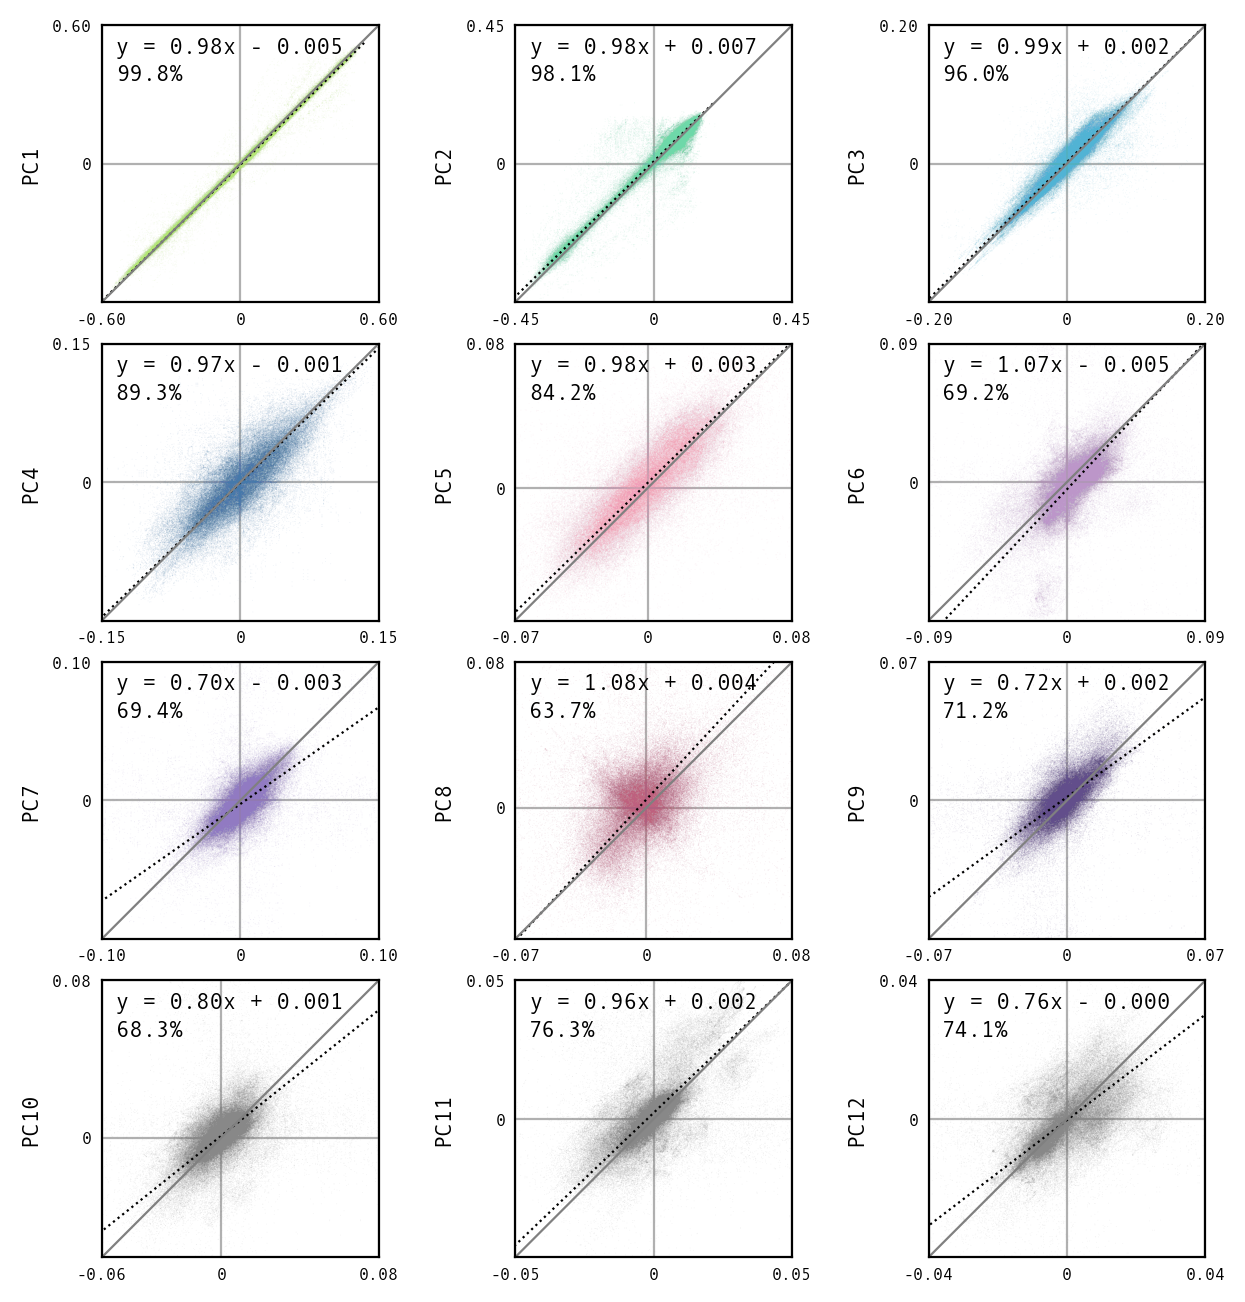

In [4]:
plt.close("all")
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df, obstacle=0
)
print_symmetry_summary(left_right_scores, label="All non-obstacle flights")
fig, axs = plot_left_right(left_right_scores, score_5, score_95, alpha=CONFIG["alpha_all"])
save_figure(fig, f'{CONFIG["fig_dir"]}/S11_symmetry_all_nonobstacle.pdf', rasterize=True)

**Interpretation.** The baseline confirms that the major planform modes (1–4) show MA slopes close to 1.0 with near-zero intercepts, indicating strong bilateral coupling during straight flight. Higher modes show progressively weaker coupling -- the scatter broadens and slopes deviate further from unity -- consistent with these modes capturing finer, less coordinated adjustments. This baseline establishes the reference against which we compare specific flight phases below.

## Flapping Phase (Acceleration)

During the first half of 9 m and 12 m flights, hawks are actively flapping to gain speed. We expect the tightest bilateral coupling here: coordinated wing beats require symmetric morphing to produce balanced thrust. Any systematic left-right differences during flapping would suggest asymmetric force production.

Experienced hawks only (excluding naive flights).

Number of frames: 10839
Number of flights: 233

--- Flapping -- experienced ---
  Mode     Slope  Intercept   Var %  Coupling
  PC01     0.984     0.0003  100.0%  strong
  PC02     0.985     0.0064   99.7%  strong
  PC03     1.067     0.0054   96.5%  moderate
  PC04     1.168     0.0007   83.3%  weak
  PC05     1.027     0.0016   89.5%  strong
  PC06     1.234    -0.0013   92.1%  weak
  PC07     0.972     0.0024   90.4%  strong
  PC08     0.858    -0.0006   89.9%  moderate
  PC09     1.290     0.0039   84.7%  weak
  PC10     1.171    -0.0012   83.1%  weak
  PC11     0.925     0.0016   89.1%  moderate
  PC12     0.990    -0.0005   88.7%  strong


Saved: ../../figures/supplementary/S11_symmetry_flapping_experienced.pdf


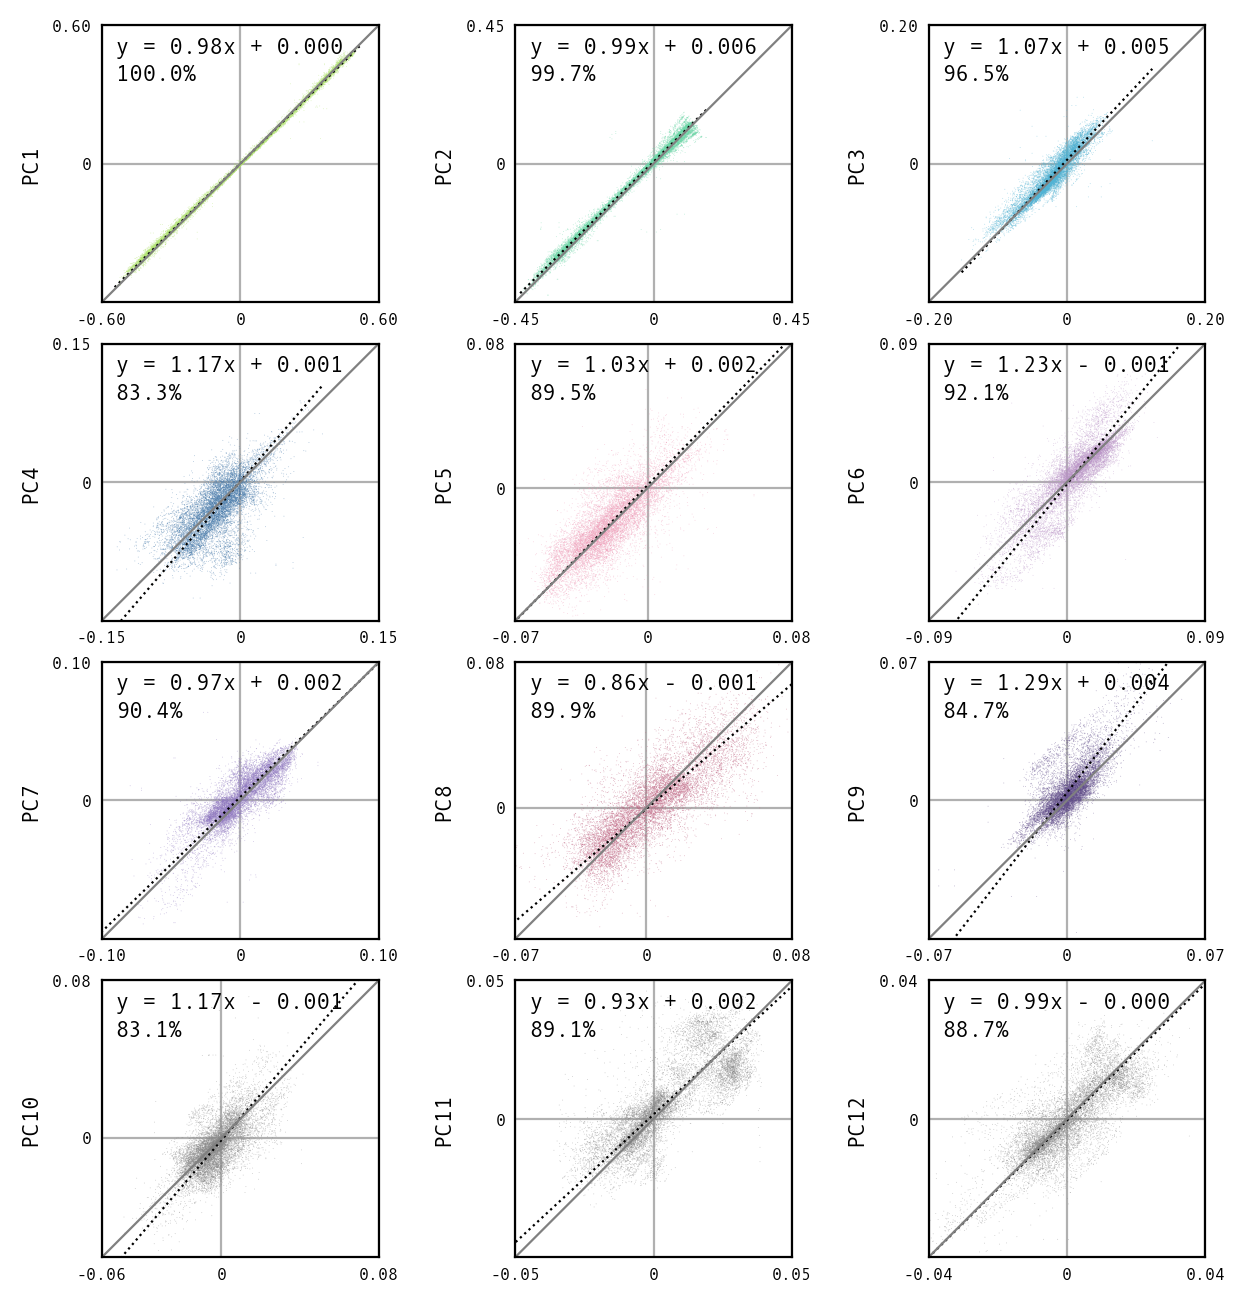

In [5]:
plt.close("all")
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df,
    obstacle=0,
    naive=0,
    perchDist=["9", "12"],
    horzdist="first_half",
)
print_symmetry_summary(left_right_scores, label="Flapping -- experienced")
fig, axs = plot_left_right(left_right_scores, score_5, score_95, alpha=CONFIG["alpha_flapping"])
save_figure(fig, f'{CONFIG["fig_dir"]}/S11_symmetry_flapping_experienced.pdf', rasterize=True)

**Interpretation.** As expected, flapping shows the tightest bilateral coupling of any flight phase. The dominant modes maintain slopes very close to 1.0 and intercepts near zero, confirming that active wingbeats are highly symmetric. Even the mid-range modes (3–6) show tighter coupling than in the all-flights baseline, consistent with the aerodynamic demands of thrust production requiring coordinated bilateral morphing.

## Gliding Phase (Deceleration)

During the second half of 9 m and 12 m flights, hawks transition to gliding and decelerating as they approach the perch. We expect greater left-right independence than during flapping: fine-tuned aerodynamic adjustments for the approach do not require strict bilateral symmetry, and subtle corrections for crosswinds or landing angle may be asymmetric.

Experienced hawks only.

Number of frames: 15840
Number of flights: 229

--- Gliding -- experienced ---
  Mode     Slope  Intercept   Var %  Coupling
  PC01     0.981    -0.0049   99.9%  strong
  PC02     0.967     0.0012   95.7%  strong
  PC03     0.950    -0.0012   98.3%  moderate
  PC04     0.918    -0.0009   77.7%  moderate
  PC05     0.992    -0.0005   88.2%  strong
  PC06     0.791     0.0018   71.2%  weak
  PC07     0.813    -0.0011   73.6%  weak
  PC08     0.913    -0.0004   78.3%  moderate
  PC09     0.830     0.0011   75.0%  weak
  PC10     0.970    -0.0006   80.9%  strong
  PC11     1.237     0.0021   88.4%  weak
  PC12     1.230     0.0024   82.6%  weak


Saved: ../../figures/supplementary/S11_symmetry_gliding_experienced.pdf


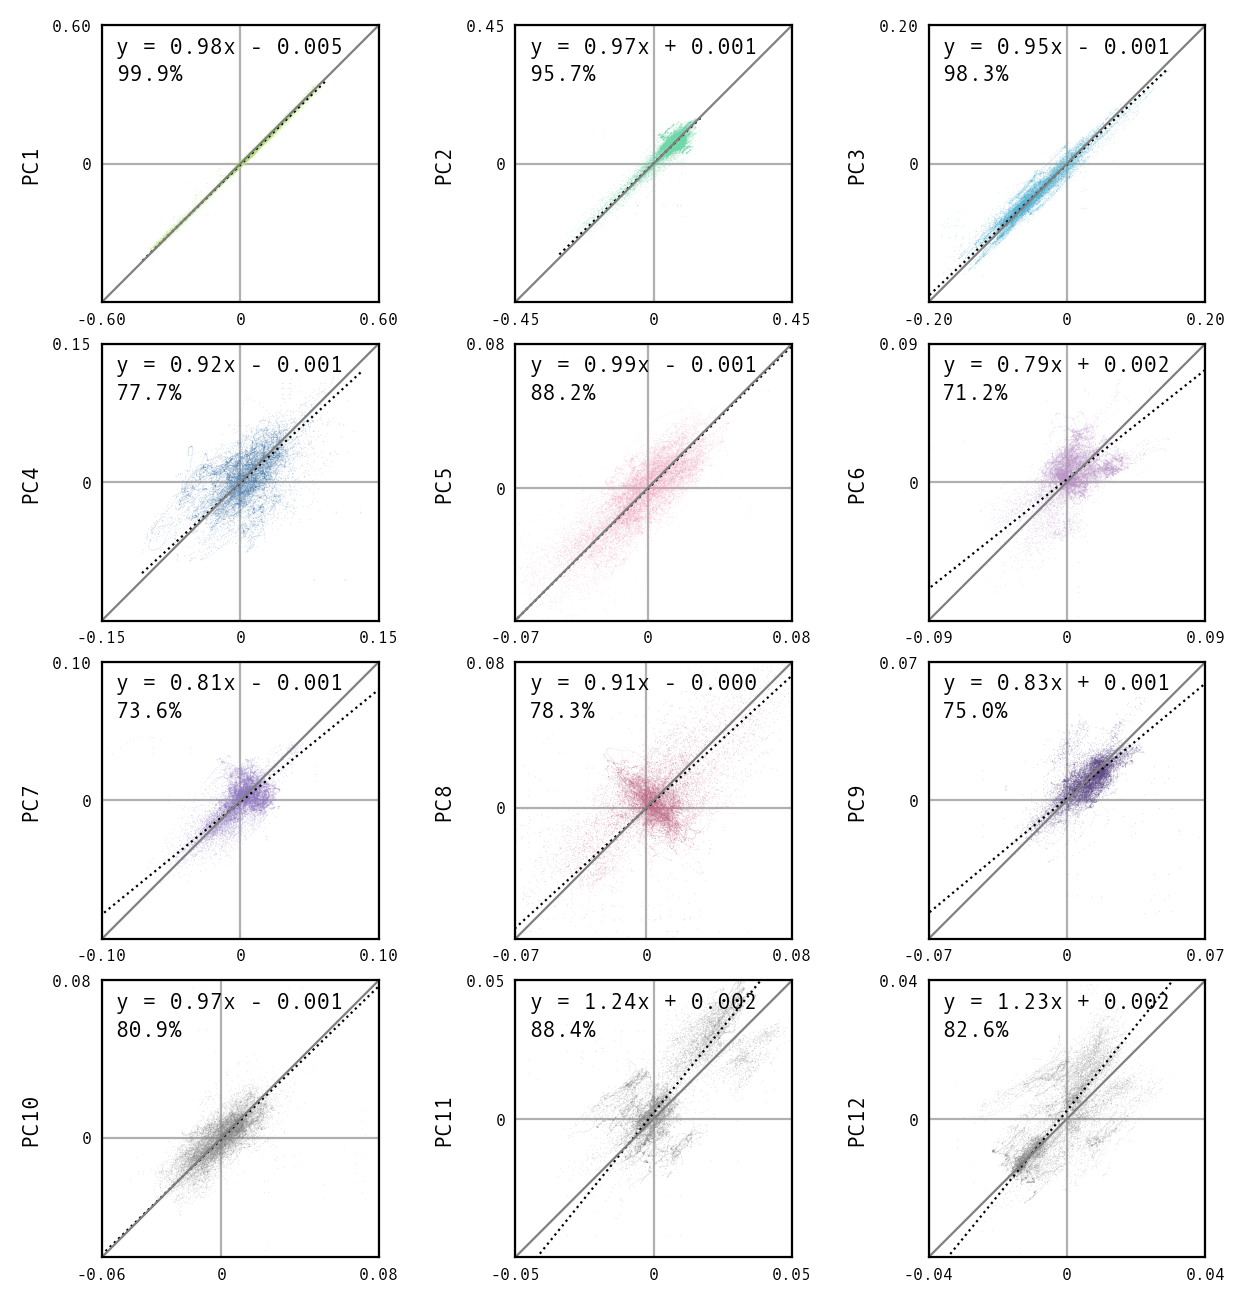

In [6]:
plt.close("all")
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df,
    obstacle=0,
    naive=0,
    perchDist=["9", "12"],
    horzdist="second_half",
)
print_symmetry_summary(left_right_scores, label="Gliding -- experienced")
fig, axs = plot_left_right(left_right_scores, score_5, score_95, alpha=CONFIG["alpha_gliding"])
save_figure(fig, f'{CONFIG["fig_dir"]}/S11_symmetry_gliding_experienced.pdf', rasterize=True)

**Interpretation.** Compared to flapping, the gliding phase shows increased left-right independence. Hand-wing adjustments and tail lowering (collective pitch) exhibit wider scatter and slopes further from unity, consistent with fine-tuned aerodynamic control where each side can be adjusted semi-independently. The dominant modes (1–2) remain tightly coupled, but modes 3–5 show notably looser bilateral coordination than during flapping -- the hawks maintain symmetric gross posture while allowing independent fine control.

## Obstacle Flights

Obstacle flights force asymmetric manoeuvres as the hawk banks around the obstacle. We separate the approach (before the obstacle) from the recovery (after), as these phases place different aerodynamic demands on the wings and tail.

### Before the Obstacle

The hawk is approaching the obstacle and preparing to bank. We expect wings to be pitched more negatively (anticipatory posture) and the tail to become more spread and asymmetric as the hawk sets up for the turn. Experienced hawks, 9 m flights only.

Number of frames: 6347
Number of flights: 180

--- Obstacle -- before ---
  Mode     Slope  Intercept   Var %  Coupling
  PC01     0.990     0.0011  100.0%  strong
  PC02     1.003     0.0109   99.5%  strong
  PC03     1.159     0.0039   96.6%  weak
  PC04     1.264     0.0124   77.6%  weak
  PC05     1.132     0.0017   83.6%  moderate
  PC06     0.970     0.0035   91.8%  strong
  PC07     0.938     0.0029   91.5%  moderate
  PC08     0.818    -0.0024   86.2%  weak
  PC09     1.039     0.0025   86.1%  strong
  PC10     1.003    -0.0023   83.4%  strong
  PC11     0.994     0.0004   95.4%  strong
  PC12     1.014    -0.0002   86.4%  strong


Saved: ../../figures/supplementary/S11_symmetry_obstacle_before.pdf


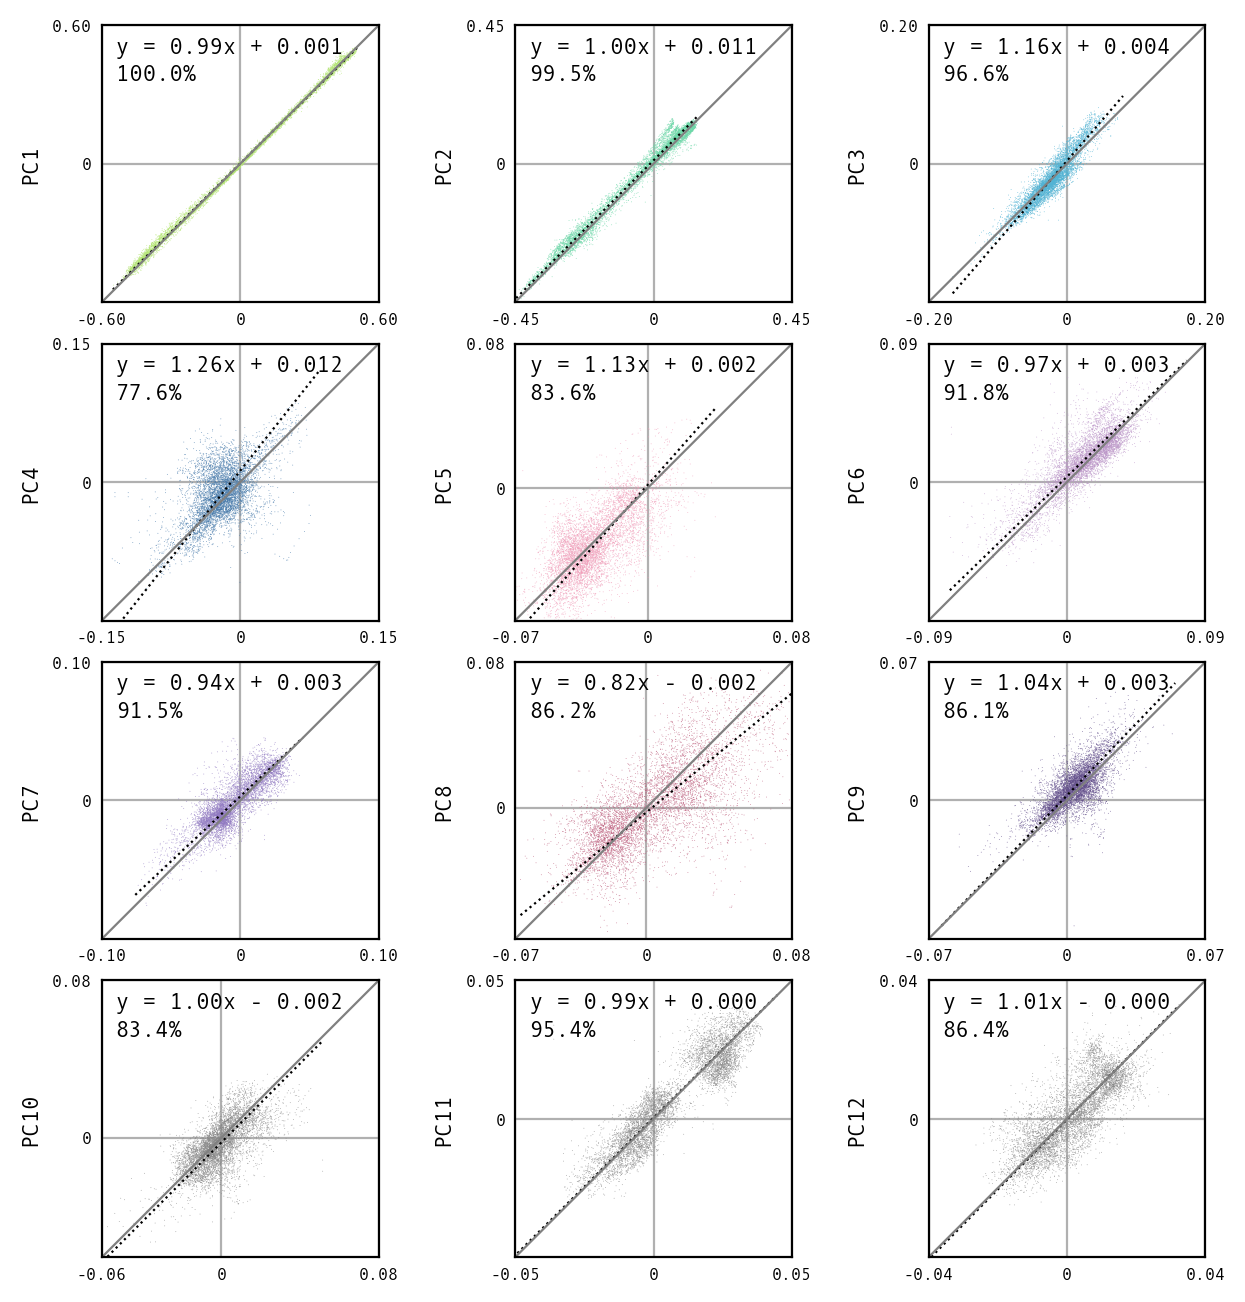

In [7]:
plt.close("all")
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df,
    obstacle=1,
    naive=0,
    perchDist=["9"],
    horzdist="first_half",
)
print_symmetry_summary(left_right_scores, label="Obstacle -- before")
fig, axs = plot_left_right(left_right_scores, score_5, score_95, alpha=CONFIG["alpha_obstacle"])
save_figure(fig, f'{CONFIG["fig_dir"]}/S11_symmetry_obstacle_before.pdf', rasterize=True)

**Interpretation.** The approach phase shows the onset of asymmetry. Tail-related modes show wider scatter and non-zero intercepts, indicating that the tail is used asymmetrically as the hawk prepares the banked turn. Wing modes remain more coupled than tail modes, suggesting the wings maintain relatively coordinated posture while the tail initiates directional control.

### After the Obstacle

Post-obstacle, the hawk has completed the banked turn and is stabilising toward the perch. We expect yaw to be stabilised and roll decreased, but greater asymmetry in hand-wing shape changes and tail spreading. Anti-symmetric collective pitching (one side pitched up, the other down) would indicate tail banking for yaw stabilisation -- a "helicopter-like" steering mechanism (Ros et al., 2011).

Number of frames: 8574
Number of flights: 191

--- Obstacle -- after ---
  Mode     Slope  Intercept   Var %  Coupling
  PC01     0.975    -0.0066   99.9%  strong
  PC02     0.971    -0.0045   94.3%  strong
  PC03     0.970     0.0041   95.8%  strong
  PC04     1.435     0.0027   66.6%  weak
  PC05     1.013     0.0024   88.3%  strong
  PC06     0.688     0.0010   61.9%  weak
  PC07     0.995    -0.0052   59.6%  strong
  PC08     0.715     0.0034   63.1%  weak
  PC09     1.093    -0.0025   81.4%  moderate
  PC10     1.080     0.0003   83.2%  moderate
  PC11     1.043    -0.0002   86.7%  strong
  PC12     1.922     0.0009   79.7%  weak


Saved: ../../figures/supplementary/S11_symmetry_obstacle_after.pdf


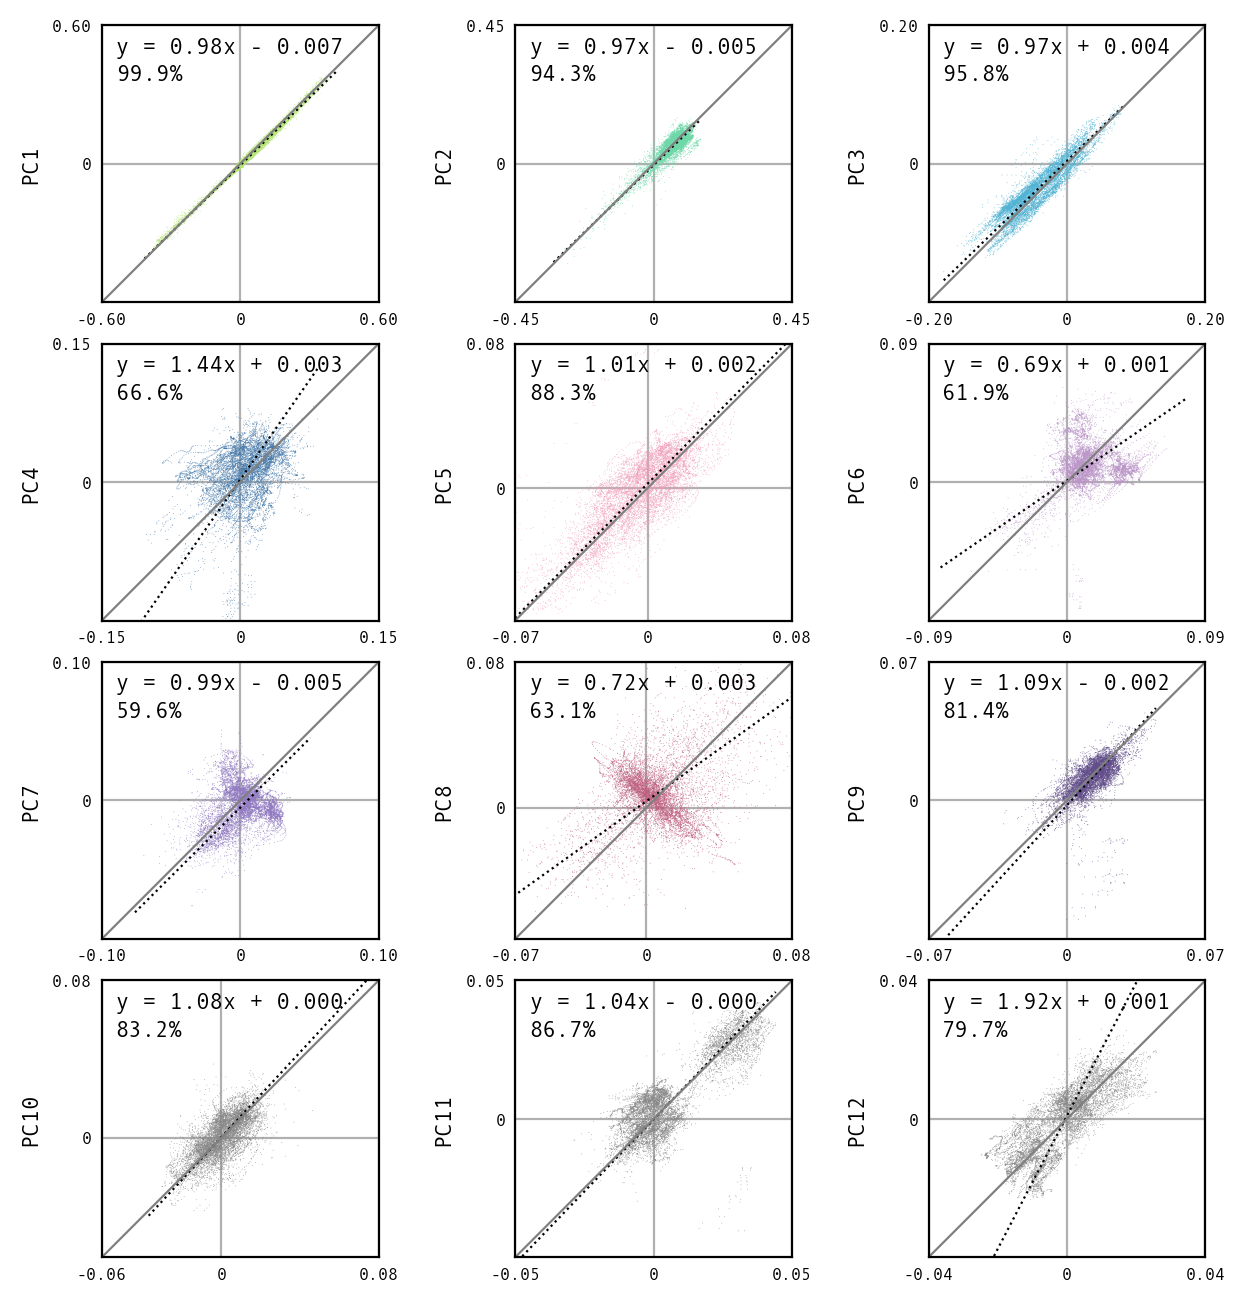

In [8]:
plt.close("all")
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df,
    obstacle=1,
    naive=0,
    perchDist=["9"],
    horzdist="second_half",
)
print_symmetry_summary(left_right_scores, label="Obstacle -- after")
fig, axs = plot_left_right(left_right_scores, score_5, score_95, alpha=CONFIG["alpha_obstacle"])
save_figure(fig, f'{CONFIG["fig_dir"]}/S11_symmetry_obstacle_after.pdf', rasterize=True)

**Interpretation.** The post-obstacle phase shows the clearest asymmetric signatures. Hand-wing shape changes and tail spreading exhibit greater left-right independence, with anti-symmetric collective pitching (negative MA slope or large intercept offset in the relevant tail modes) indicating that the tail is banked -- one side pitched up while the other is pitched down. This is consistent with tail banking for yaw stabilisation as the hawk steers back toward the perch after the turn.

## Naive Hawks

Naive (first-year) hawks have less flight experience. We expect juveniles to show more left-right independent morphing compared to experienced hawks, suggesting that bilateral coordination improves with practice. The difference should be most pronounced in modes 3–5 (sweep, tail spread, counter-pitching), where experienced hawks achieve tighter bilateral coupling.

### Naive -- Flapping Phase

Number of frames: 30867
Number of flights: 606

--- Naive -- flapping ---
  Mode     Slope  Intercept   Var %  Coupling
  PC01     0.983    -0.0018   99.8%  strong
  PC02     0.985     0.0074   98.2%  strong
  PC03     0.973     0.0050   91.7%  strong
  PC04     1.009     0.0030   85.0%  strong
  PC05     0.921     0.0019   76.5%  moderate
  PC06     1.193    -0.0054   68.3%  weak
  PC07     0.655    -0.0010   67.3%  weak
  PC08     1.300     0.0003   67.0%  weak
  PC09     0.666    -0.0004   68.4%  weak
  PC10     0.676     0.0018   70.4%  weak
  PC11     0.737     0.0017   68.6%  weak
  PC12     0.673    -0.0002   74.6%  weak


Saved: ../../figures/supplementary/S11_symmetry_naive_flapping.pdf


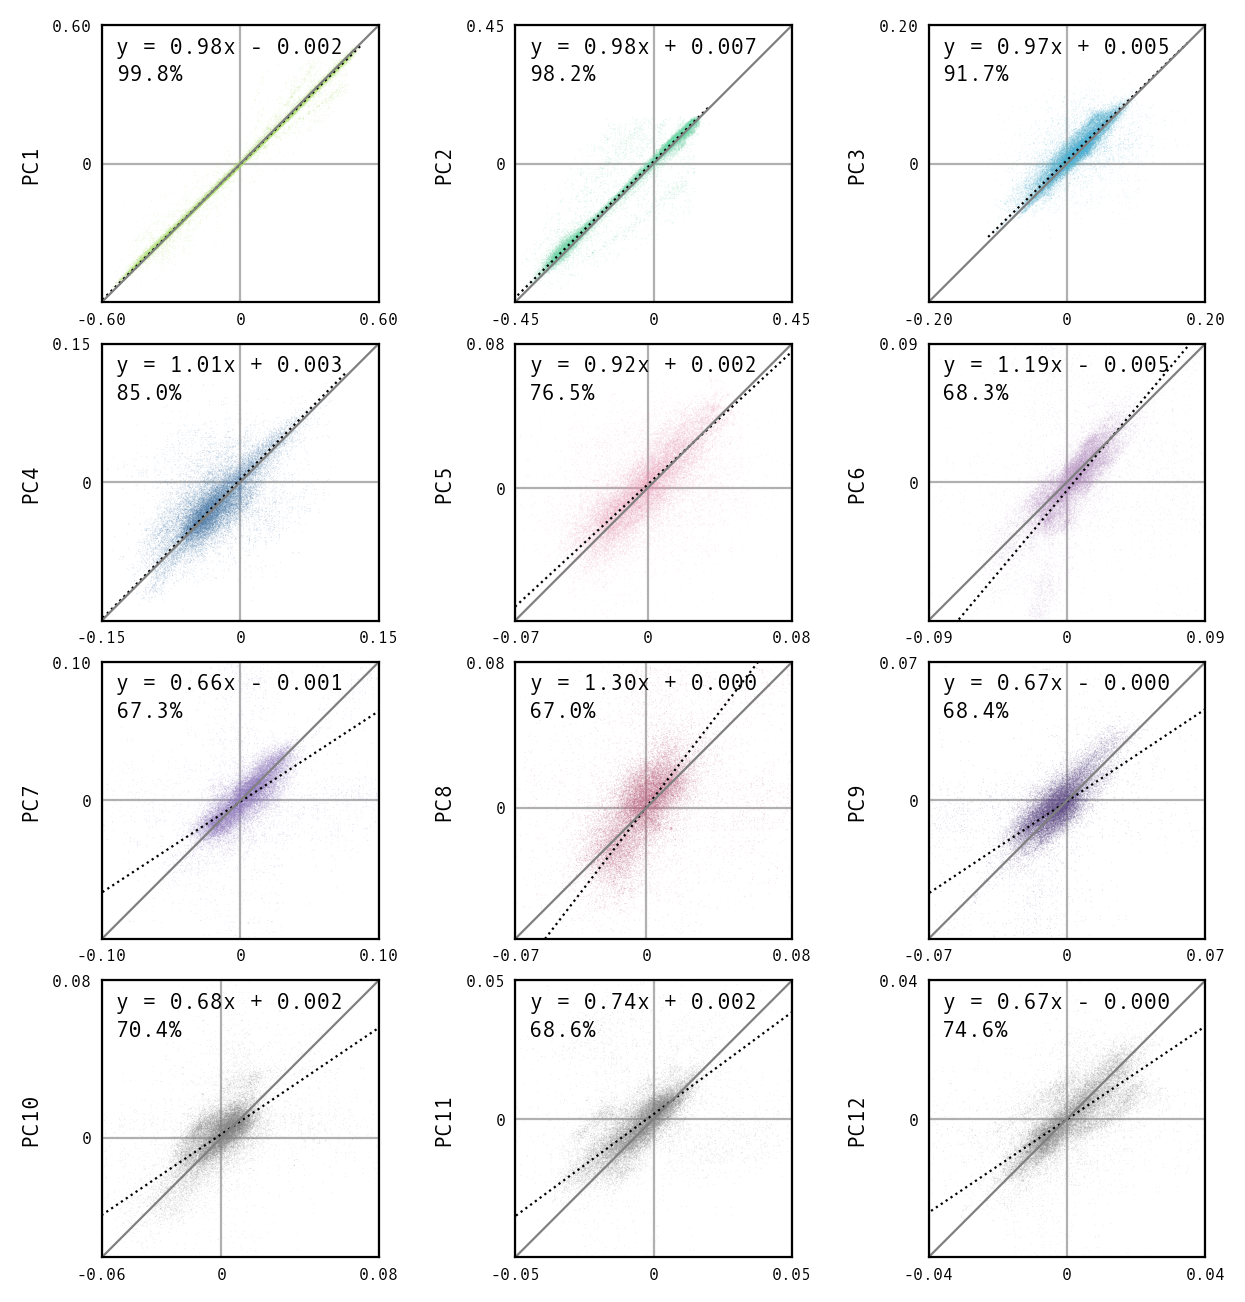

In [9]:
plt.close("all")
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df,
    obstacle=0,
    naive=1,
    perchDist=["9", "12"],
    horzdist="first_half",
)
print_symmetry_summary(left_right_scores, label="Naive -- flapping")
fig, axs = plot_left_right(left_right_scores, score_5, score_95, alpha=CONFIG["alpha_naive"])
save_figure(fig, f'{CONFIG["fig_dir"]}/S11_symmetry_naive_flapping.pdf', rasterize=True)

**Interpretation.** Naive hawks show looser bilateral coupling even during flapping -- the phase where experienced hawks are most tightly coupled. Modes 3–5 in particular exhibit wider scatter and slopes further from unity than their experienced counterparts, suggesting that juveniles have not yet developed the tight bilateral coordination seen in experienced birds. The dominant modes (1–2) remain reasonably coupled, indicating that the gross wing lifting and spreading movements are symmetric even in inexperienced hawks.

### Naive -- Gliding Phase

Number of frames: 34818
Number of flights: 560

--- Naive -- gliding ---
  Mode     Slope  Intercept   Var %  Coupling
  PC01     0.988    -0.0080   99.7%  strong
  PC02     0.916     0.0131   88.6%  moderate
  PC03     1.012     0.0013   95.7%  strong
  PC04     0.960     0.0016   88.9%  strong
  PC05     1.027     0.0018   85.9%  strong
  PC06     1.861    -0.0108   70.1%  weak
  PC07     0.550    -0.0036   67.8%  weak
  PC08    -0.478    -0.0027   53.9%  weak
  PC09     0.697    -0.0005   70.1%  weak
  PC10     0.614     0.0034   68.2%  weak
  PC11     0.600     0.0016   67.8%  weak
  PC12     0.699     0.0002   69.9%  weak


Saved: ../../figures/supplementary/S11_symmetry_naive_gliding.pdf


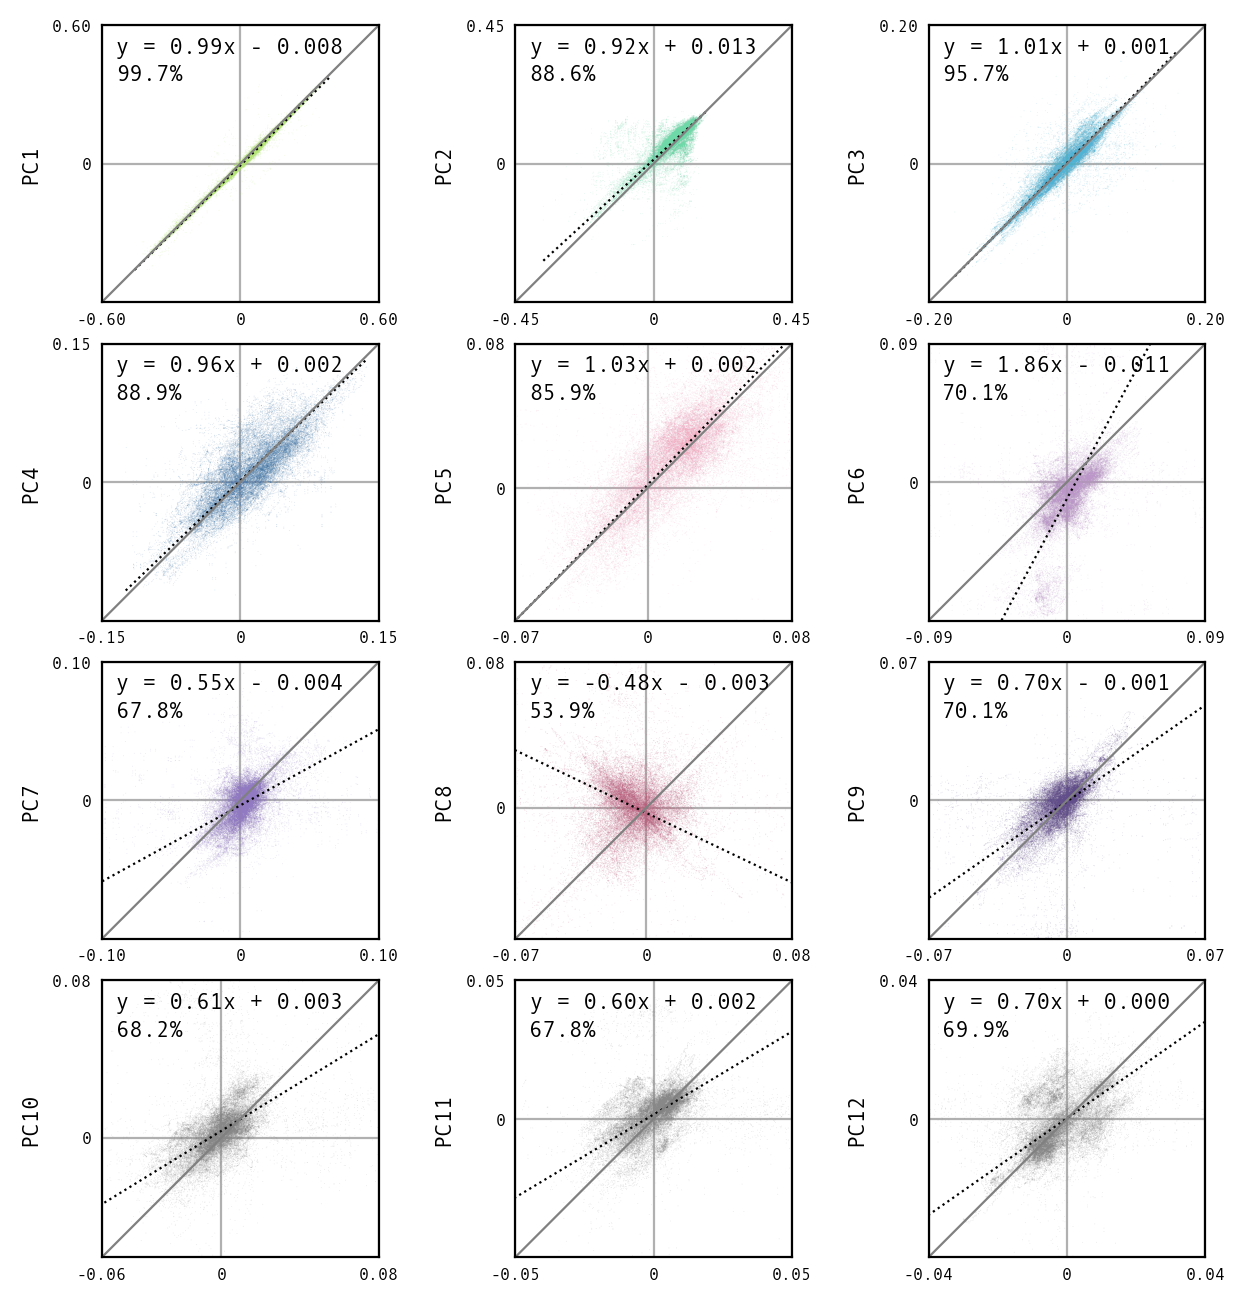

In [10]:
plt.close("all")
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df,
    obstacle=0,
    naive=1,
    perchDist=["9", "12"],
    horzdist="second_half",
)
print_symmetry_summary(left_right_scores, label="Naive -- gliding")
fig, axs = plot_left_right(left_right_scores, score_5, score_95, alpha=CONFIG["alpha_naive"])
save_figure(fig, f'{CONFIG["fig_dir"]}/S11_symmetry_naive_gliding.pdf', rasterize=True)

**Interpretation.** Naive hawks during gliding show the widest scatter and most left-right independence of any condition examined. Compared to experienced hawks gliding (which already showed more independence than flapping), juveniles exhibit even weaker bilateral coupling across most modes. This compounds the experience effect with the phase effect: both inexperience and the aerodynamic demands of deceleration contribute to reduced bilateral coordination.

## Time Series of Left and Right Scores

To see how left-right asymmetry manifests over the course of a flight, we plot the left and right scores separately against horizontal distance for a single hawk (Toothless) and a single mode (PC04 -- tail spreading). Comparing straight flights with turning flights reveals how turns introduce temporal asymmetry: in a straight flight the left and right traces should overlap, while turns should produce visible separation where one side is deflected relative to the other.

Note: this is a single-hawk, single-mode illustration. The MA regression analysis above provides the population-level statistics; this time series shows what asymmetry *looks like* within individual flights.

Saved: ../../figures/supplementary/S11_symmetry_timeseries_PC04_Toothless.pdf


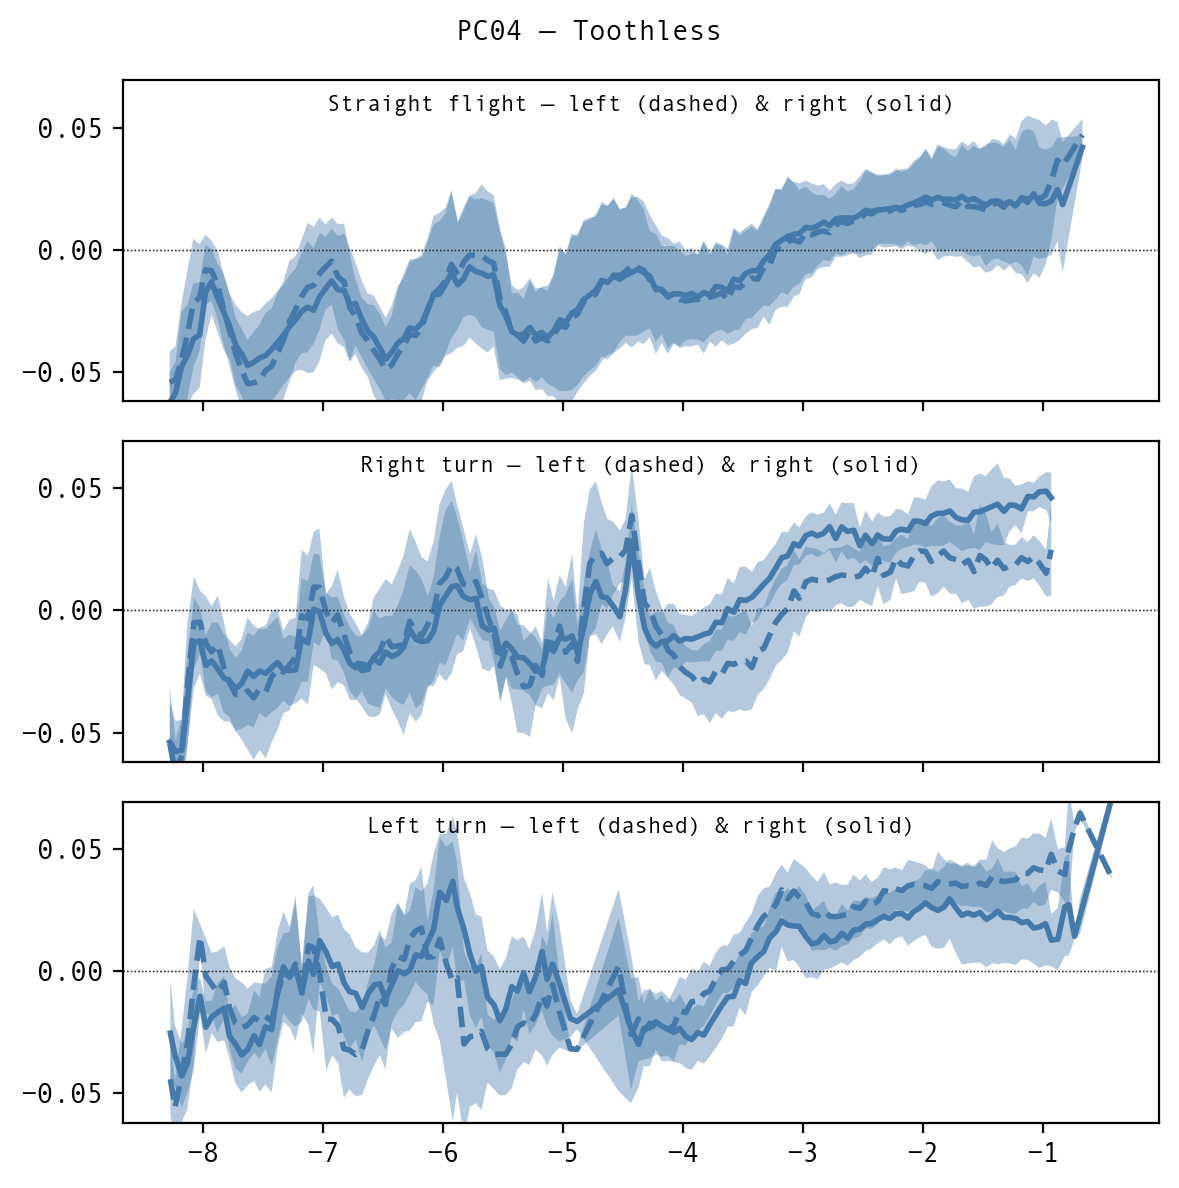

In [11]:
which_PC = "PC04"
which_hawk = "Toothless"

fig, ax = plt.subplots(3, 1, figsize=(6, 6), sharex=True, sharey=True)

# Straight flight: left and right should overlap
plot_score(scores_df, which_PC, ax=ax[0], hawkname=which_hawk,
           perchDist=9, turn='Straight', left=True, year=2020, linestyle='--')
plot_score(scores_df, which_PC, ax=ax[0], hawkname=which_hawk,
           perchDist=9, turn='Straight', left=False, year=2020)
ax[0].set_title("Straight flight — left (dashed) & right (solid)", fontsize=8, y=0.85)

# Right turn
plot_score(scores_df, which_PC, ax=ax[1], hawkname=which_hawk,
           left=True, turn='Right', linestyle='--')
plot_score(scores_df, which_PC, ax=ax[1], hawkname=which_hawk,
           left=False, turn='Right')
ax[1].set_title("Right turn — left (dashed) & right (solid)", fontsize=8, y=0.85)

# Left turn
plot_score(scores_df, which_PC, ax=ax[2], hawkname=which_hawk,
           left=True, turn='Left', linestyle='--')
plot_score(scores_df, which_PC, ax=ax[2], hawkname=which_hawk,
           left=False, turn='Left')
ax[2].set_title("Left turn — left (dashed) & right (solid)", fontsize=8, y=0.85)

plt.suptitle(f"{which_PC} — {which_hawk}", fontsize=10)
plt.tight_layout()
save_figure(fig, f'{CONFIG["fig_dir"]}/S11_symmetry_timeseries_{which_PC}_{which_hawk}.pdf')

**Interpretation.** In straight flight, the left and right PC04 traces largely overlap, confirming bilateral symmetry in tail spreading during non-manoeuvring flight. During turns, the traces separate: one side shows increased tail spread while the other decreases, producing the asymmetric tail posture that generates the yaw moment needed for turning. The separation is most pronounced near the obstacle position and persists through the recovery phase, consistent with the MA regression findings above showing greater asymmetry in obstacle flights.

## Validating the Symmetry Assumption for Modes 1 and 2

As noted earlier, the rotation correction (§5) assumes bilateral symmetry for modes 1 and 2. We now unpack this and validate it.

When PCA is applied to the bilateral (whole-shape) data, the first two components — wing lifting and wing spreading — are naturally symmetric across the left-right axis (asymmetry scores of 0.0006 and 0.0024; see §5). This is a finding about how the birds actually move: the dominant morphing patterns are bilaterally coupled regardless of whole-body orientation, consistent with the helicopter-like steering described by Ros et al. (2011).

The rotation correction exploits this natural symmetry. It projects each frame onto modes 1–2 to produce a forced-symmetric reconstruction, then uses the Kabsch algorithm to find the optimal rotation between that symmetric projection and the original markers. This rotation is removed from the data, yielding the corrected markers used for all subsequent analysis.

Because the correction *defines* the symmetric reference from modes 1–2, the corrected data has their symmetry built in by construction. All the symmetry results above for modes 3–12 depend on this assumption being correct — if modes 1–2 contained genuine asymmetric morphing, the rotation estimate would be distorted. Assessing left-right coupling from corrected scores for modes 1–2 would be circular: we would be measuring a property we assumed into the data.

The mode *definitions* (eigenvectors) are identical whether derived from corrected or uncorrected data (dot products ≥ 0.999; see §7, Figure N), but the *scores* differ because the underlying marker positions differ — corrected data has whole-body rotation removed. For modes 3+, this is the desired effect: it separates morphing from roll and yaw. For modes 1–2, the circularity means the corrected scores show artificially perfect symmetry.

To validate the assumption, we repeat the left-right comparison for modes 1–2 using scores from the **uncorrected** (pre-rotation) dataset. If the assumption is wrong, we would expect to see systematic left-right divergence, particularly during turning flights where asymmetric morphing would be most likely. We show straight flights alongside obstacle flights to compare.

Number of frames: 10839
Number of flights: 233


Saved: ../../figures/supplementary/S11_symmetry_unrotated_straight.pdf
Number of frames: 14921
Number of flights: 194


Saved: ../../figures/supplementary/S11_symmetry_unrotated_obstacle.pdf


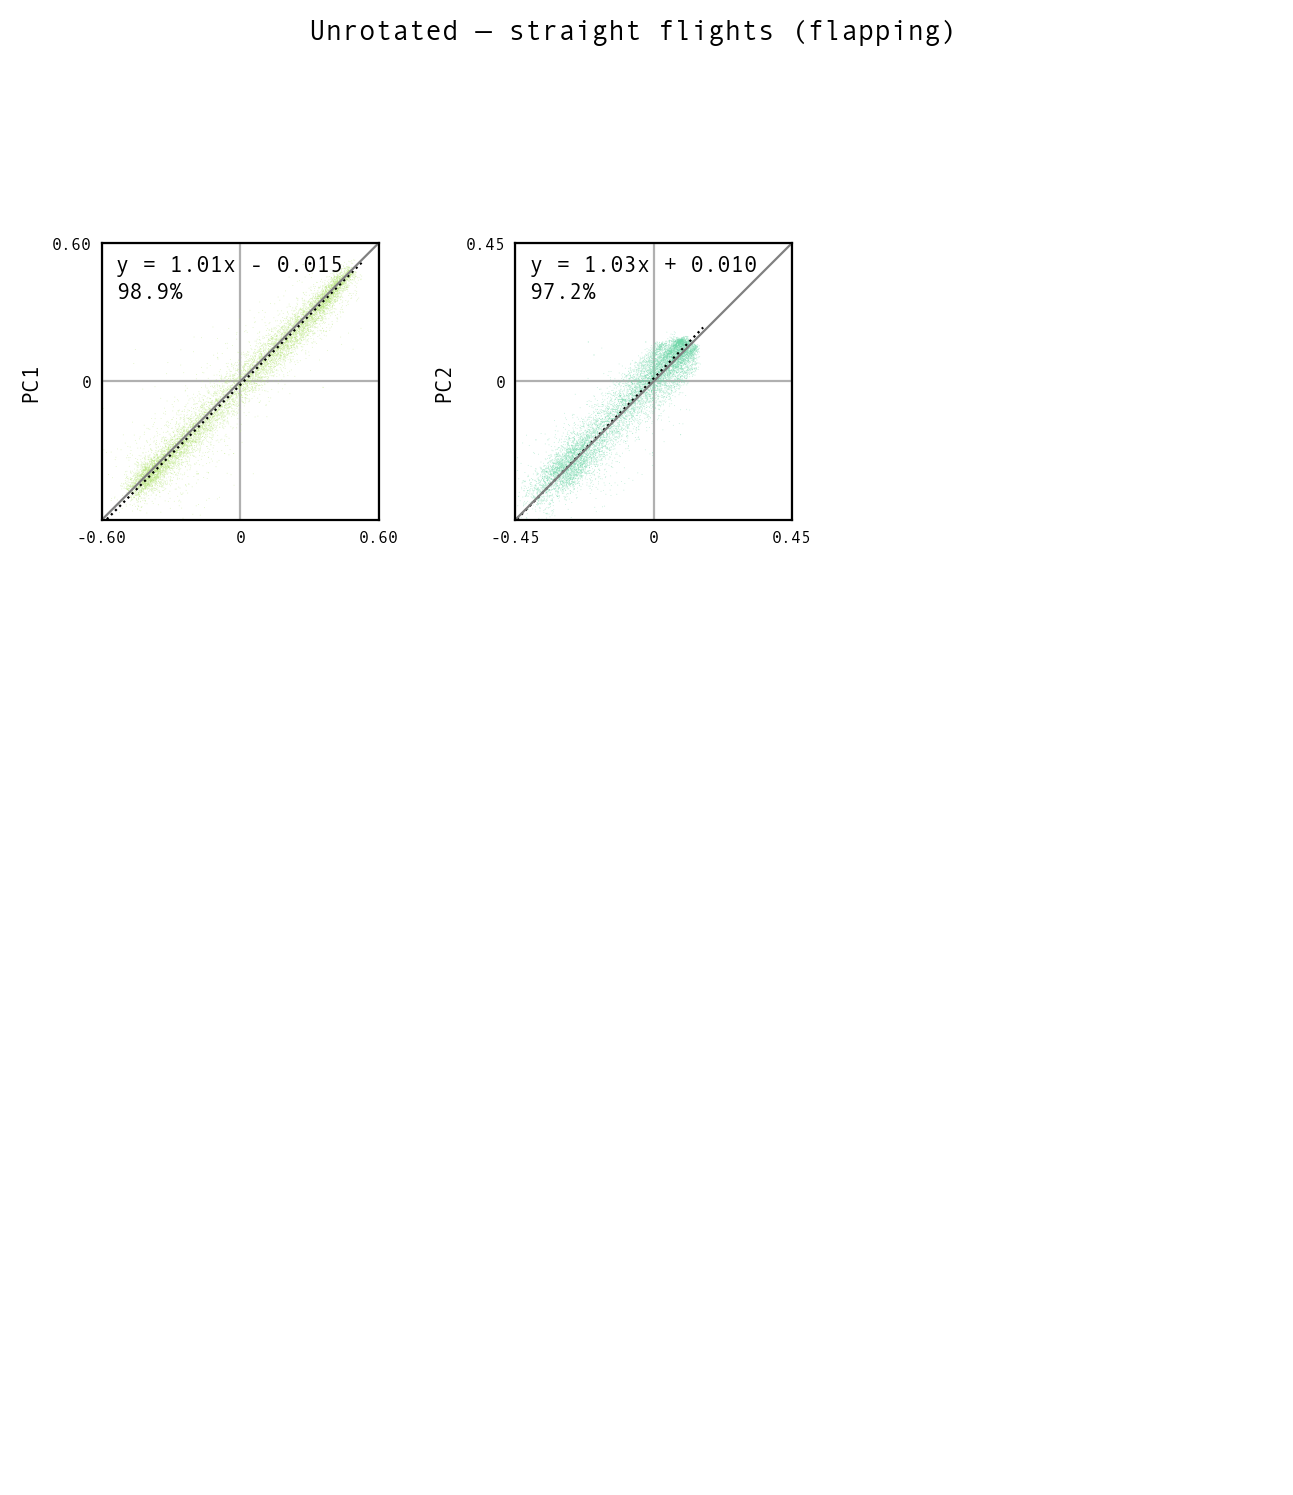

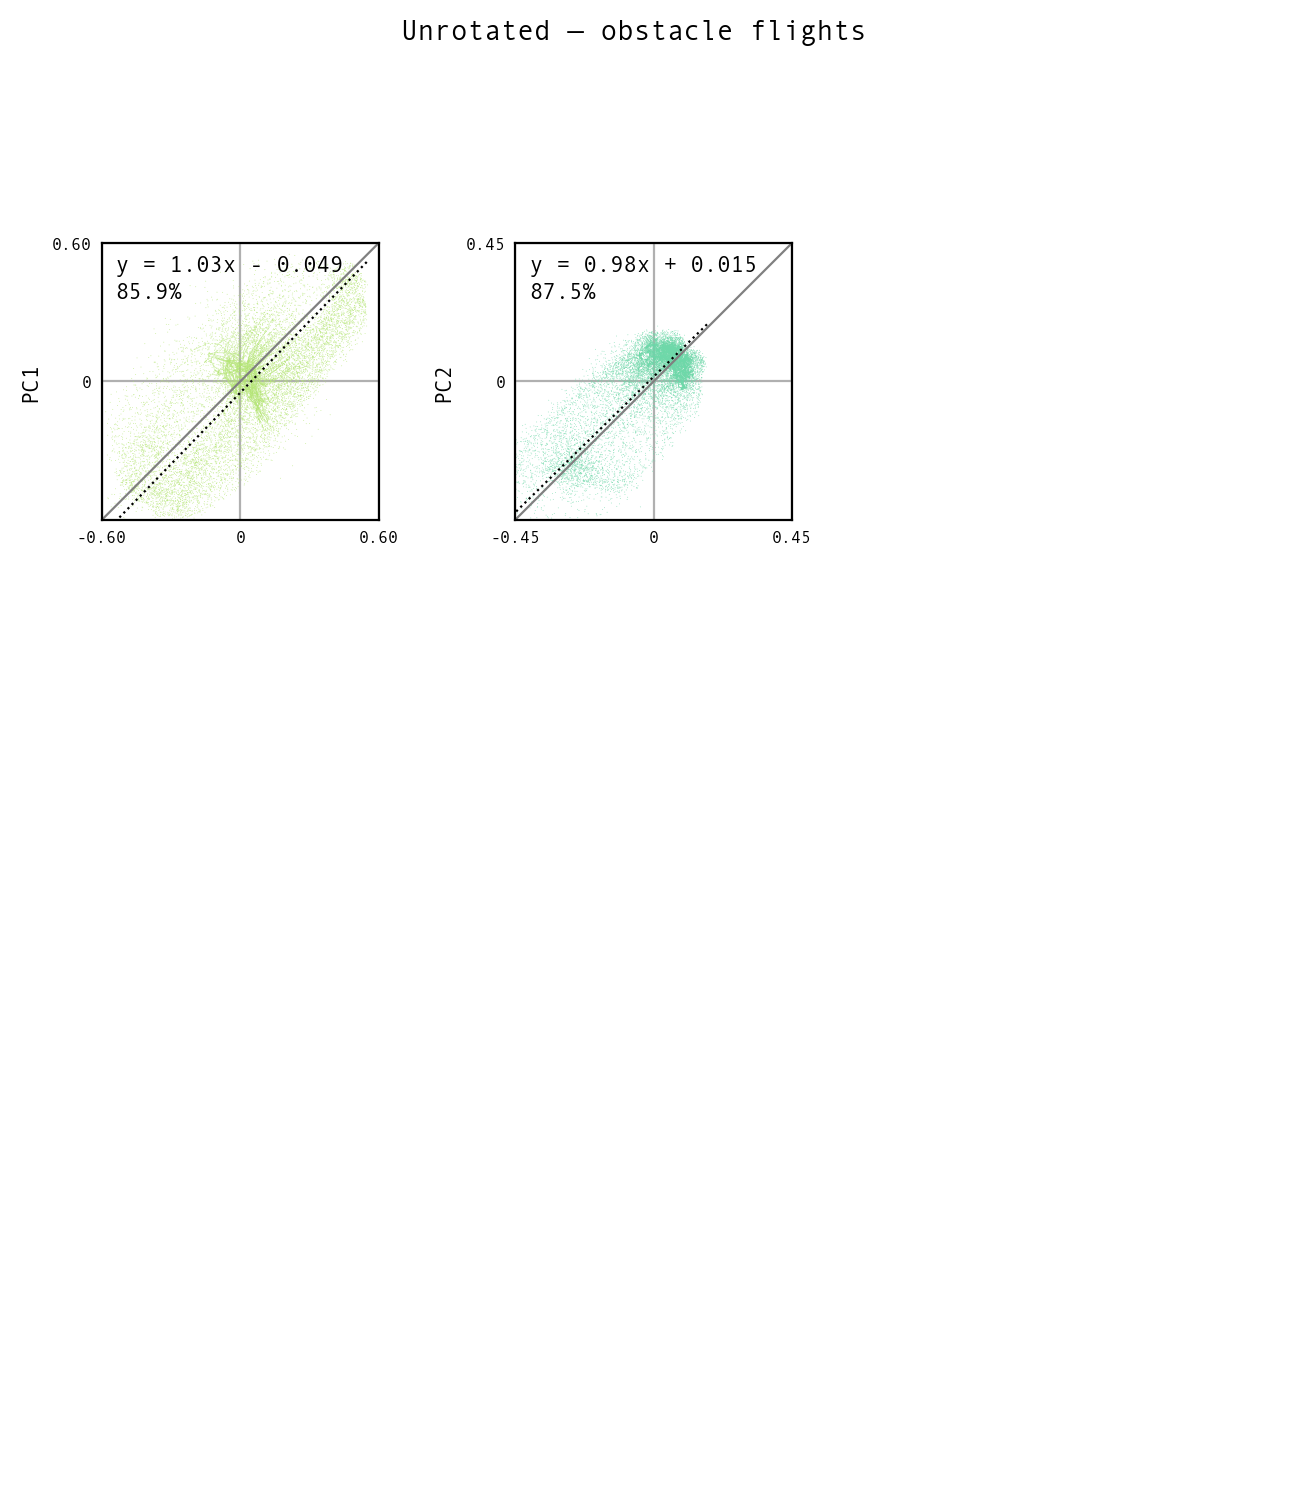

In [12]:
# Load uncorrected (pre-rotation) scores
scores_df_norot = pd.read_csv("../../data/unilateral/scores_binned_no_rotation.csv")

# --- Straight flights (experienced, 9m & 12m, flapping phase) ---
plt.close("all")
left_right_norot, score_5, score_95 = prepare_left_right_comparison(
    scores_df_norot,
    obstacle=0,
    naive=0,
    perchDist=["9", "12"],
    horzdist="first_half",
)
fig, axs = plot_left_right_just_two(left_right_norot, score_5, score_95, alpha=0.5)
fig.suptitle("Unrotated — straight flights (flapping)", fontsize=10, y=1.02)
save_figure(fig, f'{CONFIG["fig_dir"]}/S11_symmetry_unrotated_straight.pdf', rasterize=True)

# --- Obstacle flights (experienced, 9m) ---
# plt.close("all")
left_right_norot, score_5, score_95 = prepare_left_right_comparison(
    scores_df_norot,
    obstacle=1,
    naive=0,
    perchDist=["9"],
)
fig, axs = plot_left_right_just_two(left_right_norot, score_5, score_95, alpha=0.8)
fig.suptitle("Unrotated — obstacle flights", fontsize=10, y=1.02)
save_figure(fig, f'{CONFIG["fig_dir"]}/S11_symmetry_unrotated_obstacle.pdf', rasterize=True)

**Interpretation.** In straight flights, modes 1 and 2 sit tightly along the line of symmetry even without rotation correction — confirming that wing lifting and wing spreading are genuinely bilaterally symmetric movements.

In obstacle flights, the characteristic "looped" pattern appears: the scatter traces elliptical paths around the diagonal rather than diverging from it. This looping is the signature of whole-body roll and yaw being projected onto the left-right score axes — a symmetric wing movement viewed from a banking body looks transiently asymmetric. Crucially, the loops are centred on the line of symmetry, not offset from it, which means there is no persistent left-right morphing difference underlying the rotation.

This validates the assumption used for rotation correction: modes 1 and 2 do not contain asymmetric morphing, even during banked turns. The apparent asymmetry in unrotated obstacle-flight data is entirely attributable to whole-body rotation — consistent with the helicopter-like steering mechanism (Ros et al., 2011) where hawks redirect aerodynamic forces by reorienting the whole body rather than producing asymmetric wing strokes.

## Summary

Left-right morphing symmetry varies systematically across flight contexts:

- **Flapping (acceleration):** The tightest bilateral coupling of any condition. Modes 1–4 show MA slopes very close to 1.0, and even the mid-range modes (3–6) are more tightly coupled than in the all-flights baseline. Coordinated wing beats require symmetric morphing for balanced thrust.

- **Gliding (deceleration):** The dominant modes (1–2) remain tightly coupled, but modes 3–5 (sweep, tail spread, counter-pitching) show notably more left-right independence than during flapping. This is consistent with fine aerodynamic control during approach, where each side can be adjusted semi-independently.

- **Obstacle — before:** Tail-related modes begin to show asymmetry as the hawk prepares the banked turn. Wing modes remain relatively coupled, suggesting the tail initiates directional control.

- **Obstacle — after:** The clearest asymmetric signatures. Hand-wing shape changes and tail spreading show greater independence, with anti-symmetric collective pitching indicating tail banking for yaw stabilisation.

- **Naive vs experienced:** Juveniles show looser bilateral coupling than experienced hawks across most modes, particularly 3–5. The difference is present even during flapping, and compounds with the gliding-phase effect. This suggests bilateral coordination is a learned skill that improves with flight experience.

- **Time series:** Within individual flights, left-right separation during turns is spatially localised around the manoeuvre point and returns toward symmetry in straight segments.

- **Modes 1–2 validation:** Using uncorrected (pre-rotation) data, wing lifting and wing spreading are confirmed as genuinely bilaterally symmetric even during banked turns. The "looped" scatter pattern in obstacle flights is attributable to whole-body rotation, not asymmetric morphing — consistent with the helicopter-like steering mechanism (Ros et al., 2011) and validating the rotation correction procedure.

---

## References

- Ros, I. G., Bassman, L. C., Badger, M. A., Pierson, A. N. & Biewener, A. A. (2011). Pigeons steer like helicopters and generate down- and upstroke lift during low speed turns. *Proceedings of the National Academy of Sciences*, 108, 19990–19995.